In [1]:
import numpy as np
import pandas as pd
import re
import random
import contractions
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

from keras.models import Model
import tensorflow as tf
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, SimpleRNN, Input, SpatialDropout1D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


2026-06-12 19:59:59.972967: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-12 20:00:00.683430: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-12 20:00:03.144015: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
import os
print(os.getcwd())
print(os.listdir())

/home/davidsales/Documentos/Coding/Main_HDL/CI_Dgital_F3/lstm_implementation_hdl/Training NN's/LSTM Final Model
['processamento_para_sv.ipynb', 'imdb movie reviews sentiment analysis - test version.ipynb', 'imdb movie reviews sentiment analysis - original version.ipynb', 'layer_outputs.txt', 'weights_lstm.mem', 'weights_mlp.mem', 'IMDB Dataset.csv']


In [3]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')   # dependendo da versão do NLTK
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /home/davidsales/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/davidsales/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/davidsales/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/davidsales/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /home/davidsales/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [4]:
df = pd.read_csv("IMDB Dataset.csv")

In [5]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [6]:
def preprocess(text):
    text = re.sub(r'\\', '', text)
    text = contractions.fix(text)

    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[\d\W]+', ' ', text)
    text = re.sub(r'\s{2,}', ' ', text)
    text = text.strip()

    tokens = word_tokenize(text)
    
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()

    tokens = [token for token in tokens if token not in stop_words]
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    tokens = [t for t in tokens if len(t) >= 3]

    return " ".join(tokens)

In [7]:
random_num = random.randrange(len(df))

sample_text = df.iloc[random_num]['review']
sample_text

'(r#97)<br /><br />There is one good thing about this poor man\'s Pokémon (make of that what you will): the opening theme. It has to be the coolest theme music of any sloppily dubbed Japanese made-for-the-consumers-oops-I-mean-the-young-fans anime TV show. Unfortunately there was need to add some sort of show after the opening theme. And they just couldn\'t come up with something more interesting than people arguing loudly about whose cards are better than the others\' cards. Freud would have a field day, unfortunately I can\'t imagine why any kids would want to sit through a show where dialogue written by a thousand monkeys in five minutes takes up 98% of the running time.<br /><br />"My Uber-Fantastical Doomsday Creature of Ultimate Doom will take your measly Pyramid Diamond Animal in a single strike! Can\'t you see that you have no chance of winning this battle, you fool?! HAHAHAHHAHHAHA!"<br /><br />"Oh yeah? Well watch this! I am about to use my Destruction Force Delta Times Pie C

In [8]:
print(preprocess(df.iloc[random_num]['review']))

one good thing poor man pokémon make opening theme coolest theme music sloppily dubbed japanese made consumer oops mean young fan anime show unfortunately need add sort show opening theme could come something interesting people arguing loudly whose card better others card freud would field day unfortunately imagine kid would want sit show dialogue written thousand monkey five minute take running time uber fantastical doomsday creature ultimate doom take measly pyramid diamond animal single strike see chance winning battle fool hahahahhahhaha yeah well watch use destruction force delta time pie card eradicates every single one power muncher render uber fantastical doomsday creature ultimate doom destroy beyond significance attack useless bet see one coming seriously ever show talk whereas another crappy kid show used watch namely commercial phenomenon pokémon every soccer mum pet peeve least monster courtesy duke every quiet word roger ebert clockwork orange review plain talky boring me

In [9]:
df['review'] = df['review'].apply(preprocess)

In [10]:
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

In [11]:

X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['sentiment'],
    test_size=0.2,
    random_state=42
)

In [12]:
vocab_size = 20000

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<UNK>")
tokenizer.fit_on_texts(X_train)

In [13]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [35]:
max_len = 20

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# LSTM

In [36]:
lstm_model = Sequential()

lstm_model.add(Input(shape=(max_len,)))

lstm_model.add(Embedding(input_dim=vocab_size, output_dim=4))
lstm_model.add(SpatialDropout1D(0.3))

lstm_model.add((LSTM(4, dropout=0.3)))

lstm_model.add(Dropout(0.5))

lstm_model.add(Dense(4, activation='relu'))
lstm_model.add(Dropout(0.4))

lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

lstm_model.build(input_shape=(None, max_len))
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 20, 4)          │        80,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 20, 4)          │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 4)              │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,169 (313.16 KB)

 Trainable params: 80,169 (313.16 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=1,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-5
)

In [38]:
lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=100,
    batch_size=128,   
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5151 - loss: 0.6914 - val_accuracy: 0.5422 - val_loss: 0.6802 - learning_rate: 5.0000e-04
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6659 - loss: 0.6456 - val_accuracy: 0.7552 - val_loss: 0.5873 - learning_rate: 5.0000e-04
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7246 - loss: 0.5994 - val_accuracy: 0.7775 - val_loss: 0.5524 - learning_rate: 5.0000e-04
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7439 - loss: 0.5742 - val_accuracy: 0.7843 - val_loss: 0.5329 - learning_rate: 5.0000e-04
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7556 - loss: 0.5484 - val_accuracy: 0.7826 - val_loss: 0.5184 - learning_rate: 5.0000e-04
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7690 - loss: 0.5273 - val_accuracy: 0.7814 - val_loss: 0.5109 - learning_rate: 5.0000e-04
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - acc

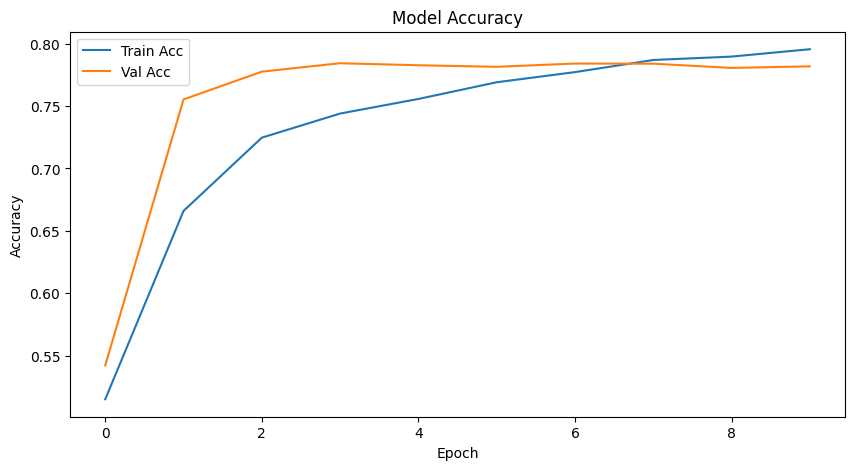

In [39]:
plt.figure(figsize=(10,5))

plt.plot(lstm_history.history['accuracy'], label='Train Acc')
plt.plot(lstm_history.history['val_accuracy'], label='Val Acc')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [40]:
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", lstm_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7831 - loss: 0.4924
Test Accuracy: 0.7831000089645386


## Confusion Matrices

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


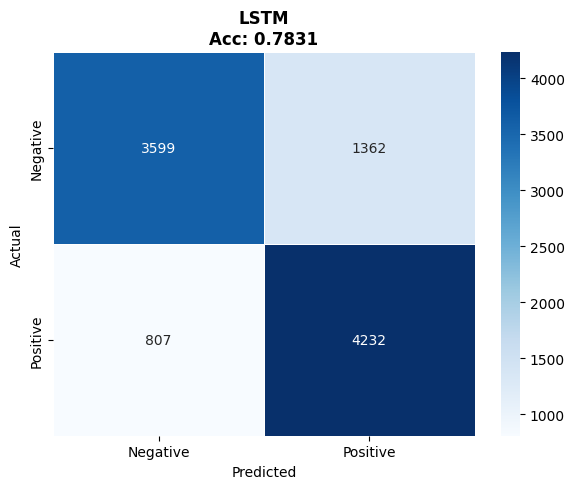

In [41]:
y_pred_lstm = (lstm_model.predict(X_test_pad) > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive'],
    linewidths=0.5,
    linecolor='white'
)

acc = (y_pred_lstm == y_test.values).mean()

plt.title(f'LSTM\nAcc: {acc:.4f}', fontsize=12, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

## Classification Reports

In [42]:
for name, pred in zip(['LSTM'], [ y_pred_lstm]):
    print(f"{'='*45}")
    print(f"  {name} — Classification Report")
    print(f"{'='*45}")
    print(classification_report(y_test, pred, target_names=['Negative','Positive']))

  LSTM — Classification Report
              precision    recall  f1-score   support

    Negative       0.82      0.73      0.77      4961
    Positive       0.76      0.84      0.80      5039

    accuracy                           0.78     10000
   macro avg       0.79      0.78      0.78     10000
weighted avg       0.79      0.78      0.78     10000



In [43]:
dummy = tf.zeros((1, max_len), dtype=tf.int32)
_ = lstm_model(dummy)

In [49]:
texto_natural = "the was probaly the worst movie that I have seen"
texto_sem_stopwords = preprocess(texto_natural)

In [50]:
texto_sem_stopwords

'probaly worst movie seen'

In [51]:
teste_qualquer = tokenizer.texts_to_sequences([texto_sem_stopwords])
teste_qualquer_pad = pad_sequences(teste_qualquer, maxlen=max_len)

In [52]:
teste_qualquer_pad

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   1, 141,   2,  35]], dtype=int32)

In [53]:
# modelo de inspeção
layer_outputs = [layer.output for layer in lstm_model.layers]

inspection_model = Model(
    inputs=lstm_model.inputs,
    outputs=layer_outputs
)

# entrada exemplo
x = teste_qualquer_pad

# forward
outputs = inspection_model.predict(x)

# salva em txt
with open("layer_outputs.txt", "w", encoding="utf-8") as f:

    for layer, output in zip(lstm_model.layers, outputs):

        f.write(f"\n{'='*60}\n")
        f.write(f"Camada: {layer.name}\n")
        f.write(f"Shape: {output.shape}\n")
        f.write(f"{'='*60}\n\n")

        # converte numpy array para string
        np.set_printoptions(threshold=np.inf)

        f.write(np.array2string(
            output,
            separator=', ',
            precision=6
        ))

        f.write("\n\n")

print("Outputs salvos em layer_outputs.txt")

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Outputs salvos em layer_outputs.txt


In [47]:

FRAC = 16
SCALE = 1 << FRAC

INT32_MAX = np.int32(2**31 - 1)
INT32_MIN = np.int32(-(2**31))

def float_to_q16(val):
    if np.isnan(val):
        return np.int32(0)
    if np.isposinf(val):
        return INT32_MAX
    if np.isneginf(val):
        return INT32_MIN
    fixed = np.round(val * SCALE)
    return np.int32(fixed)

# ============================================================
# ENDERECO DE 21 BITS
# ============================================================
def build_addr(layer, is_bias, is_lstm, gate, neuron, recurrent, idx):
    addr = 0
    addr |= (layer     & 0xF)   << 17  # bits 20-17: camada (max 16)
    addr |= (is_bias   & 0x1)   << 16  # bit 16:    bias
    addr |= (is_lstm   & 0x1)   << 15  # bit 15:    lstm
    addr |= (gate      & 0x3)   << 13  # bits 14-13: porta LSTM
    addr |= (neuron    & 0x3F)  << 7   # bits 12-7:  neuronio (max 64)
    addr |= (recurrent & 0x1)   << 6   # bit 6:     recorrente
    addr |= (idx       & 0x3F)        # bits 5-0:   indice (max 64)
    return addr

# ============================================================
# EXPORTA PESOS DA LSTM (ignorando Embedding)
# ============================================================
def export_lstm_weights(model, output_file="weights_lstm.mem"):
    print("\n" + "="*50)
    print("MODO LSTM: Exportando pesos a partir da primeira LSTM")
    print("Ignorando: Embedding e SpatialDropout1D")
    print("="*50)
    
    mem = {}
    layer_idx = 0  # camada 0 = primeira LSTM
    
    # Percorre as camadas do modelo
    for layer in model.layers:
        # Pula camadas que nao tem pesos
        if len(layer.get_weights()) == 0:
            continue
            
        # Verifica se é LSTM (incluindo Bidirectional)
        if isinstance(layer, Bidirectional):
            # Bidirectional tem 2 LSTMs (forward e backward)
            print(f"\nCamada {layer_idx}: Bidirectional LSTM")
            
            forward_lstm = layer.forward_layer
            backward_lstm = layer.backward_layer
            
            # Exporta forward LSTM
            export_lstm_core(forward_lstm, mem, layer_idx, direction=0)
            # Exporta backward LSTM (proxima camada)
            export_lstm_core(backward_lstm, mem, layer_idx + 1, direction=1)
            
            layer_idx += 2  # Duas camadas (forward e backward)
            
        elif isinstance(layer, LSTM):
            print(f"\nCamada {layer_idx}: LSTM")
            export_lstm_core(layer, mem, layer_idx, direction=0)
            layer_idx += 1
            
        elif isinstance(layer, Dense):
            print(f"\nCamada {layer_idx}: Dense")
            export_dense_core(layer, mem, layer_idx)
            layer_idx += 1
    
    # Salva arquivo
    with open(output_file, "w") as f:
        for addr in sorted(mem.keys()):
            val = np.int32(mem[addr])
            f.write(f"{int(addr):05x} {int(val) & 0xFFFFFFFF:08X}\n")
    
    print(f"\nArquivo salvo: {output_file}")
    print(f"Total de pesos: {len(mem)}")
    return mem

# ============================================================
# EXPORTA PESOS DA LSTM (core)
# ============================================================
def export_lstm_core(lstm_layer, mem, layer_idx, direction=0):
    """
    Exporta pesos de uma camada LSTM
    direction: 0 = forward, 1 = backward (apenas para identificacao)
    """
    weights = lstm_layer.get_weights()
    
    # LSTM tem 3 matrizes de pesos e 3 biases (ou 2 se usar bias=False)
    # weights[0]: kernel (input weights) - formato: (input_dim, 4 * units)
    # weights[1]: recurrent_kernel (recurrent weights) - formato: (units, 4 * units)
    # weights[2]: bias (se existir) - formato: (4 * units,)
    
    units = lstm_layer.units
    input_dim = weights[0].shape[0]
    
    # Separa os pesos para cada porta (forget, input, candidate, output)
    # Ordem: i, f, c, o (input, forget, candidate, output)
    kernel = weights[0].T  # Transpoe para (4*units, input_dim)
    recurrent_kernel = weights[1].T  # Transpoe para (4*units, units)
    
    # Bias
    has_bias = len(weights) > 2
    if has_bias:
        bias = weights[2]
    else:
        bias = np.zeros(4 * units)
    
    # Para cada porta
    #gates = ['forget', 'input', 'candidate', 'output']
    gates = ['candidate', 'forget', 'input', 'output']
    
    for gate_idx, gate_name in enumerate(gates):
        # Pesos de entrada (Wx)
        kernel_gate = kernel[gate_idx * units:(gate_idx + 1) * units, :]
        for n in range(units):
            for inp in range(input_dim):
                addr = build_addr(
                    layer=layer_idx,
                    is_bias=0,
                    is_lstm=1,
                    gate=gate_idx,
                    neuron=n,
                    recurrent=0,
                    idx=inp
                )
                mem[addr] = float_to_q16(kernel_gate[n, inp])
                
                # Mostra alguns exemplos (opcional)
                if n < 2 and inp < 2:
                    print(f"  addr=0x{addr:05X} Wx_{gate_name}[{n}][{inp}] = {kernel_gate[n, inp]:.6f}")
        
        # Pesos recorrentes (Wh)
        rec_gate = recurrent_kernel[gate_idx * units:(gate_idx + 1) * units, :]
        for n in range(units):
            for prev_n in range(units):
                addr = build_addr(
                    layer=layer_idx,
                    is_bias=0,
                    is_lstm=1,
                    gate=gate_idx,
                    neuron=n,
                    recurrent=1,
                    idx=prev_n
                )
                mem[addr] = float_to_q16(rec_gate[n, prev_n])
                
                if n < 2 and prev_n < 2:
                    print(f"  addr=0x{addr:05X} Wh_{gate_name}[{n}][{prev_n}] = {rec_gate[n, prev_n]:.6f}")
        
        # Bias
        bias_gate = bias[gate_idx * units:(gate_idx + 1) * units]
        for n in range(units):
            addr = build_addr(
                layer=layer_idx,
                is_bias=1,
                is_lstm=1,
                gate=gate_idx,
                neuron=n,
                recurrent=0,
                idx=0
            )
            mem[addr] = float_to_q16(bias_gate[n])
            
            if n < 2:
                print(f"  addr=0x{addr:05X} bias_{gate_name}[{n}] = {bias_gate[n]:.6f}")

# ============================================================
# EXPORTA PESOS DA DENSE (MLP comum)
# ============================================================
def export_dense_core(dense_layer, mem, layer_idx):
    """Exporta pesos de uma camada Dense"""
    weights = dense_layer.get_weights()
    
    if len(weights) >= 1:
        kernel = weights[0].T  # Transpoe para (output_dim, input_dim)
        n_neurons, n_inputs = kernel.shape
        
        # Pesos
        for n in range(n_neurons):
            for inp in range(n_inputs):
                addr = build_addr(
                    layer=layer_idx,
                    is_bias=0,
                    is_lstm=0,  # Nao é LSTM
                    gate=0,
                    neuron=n,
                    recurrent=0,
                    idx=inp
                )
                mem[addr] = float_to_q16(kernel[n, inp])
                
                if n < 3 and inp < 3:
                    print(f"  addr=0x{addr:05X} weight[{n}][{inp}] = {kernel[n, inp]:.6f}")
        
        # Biases
        if len(weights) >= 2:
            bias = weights[1]
            for n in range(n_neurons):
                addr = build_addr(
                    layer=layer_idx,
                    is_bias=1,
                    is_lstm=0,
                    gate=0,
                    neuron=n,
                    recurrent=0,
                    idx=0
                )
                mem[addr] = float_to_q16(bias[n])
                
                if n < 3:
                    print(f"  addr=0x{addr:05X} bias[{n}] = {bias[n]:.6f}")

# ============================================================
# EXPORTA COMO MLP (ignorando LSTM)
# ============================================================
def export_mlp_weights(model, output_file="weights_mlp.mem"):
    print("\n" + "="*50)
    print("MODO MLP: Exportando pesos como rede neural comum")
    print("Todas as camadas Dense sao consideradas")
    print("="*50)
    
    mem = {}
    layer_idx = 0
    
    for layer in model.layers:
        if len(layer.get_weights()) == 0:
            continue
            
        if isinstance(layer, Dense):
            print(f"\nCamada {layer_idx}: Dense")
            export_dense_core(layer, mem, layer_idx)
            layer_idx += 1
        elif isinstance(layer, Bidirectional) or isinstance(layer, LSTM):
            print(f"\nAviso: Pulando camada LSTM no modo MLP")
            continue
    
    with open(output_file, "w") as f:
        for addr in sorted(mem.keys()):
            val = np.int32(mem[addr])
            f.write(f"{int(addr):05x} {int(val) & 0xFFFFFFFF:08X}\n")
    
    print(f"\nArquivo salvo: {output_file}")
    print(f"Total de pesos: {len(mem)}")
    return mem

# ============================================================
# FUNCAO PRINCIPAL
# ============================================================
def export_weights(model, mode='lstm', output_file=None):
    """
    Exporta pesos do modelo
    
    Args:
        model: Modelo Keras
        mode: 'lstm' (ignora Embedding) ou 'mlp' (apenas camadas Dense)
        output_file: Nome do arquivo de saida
    """
    if mode == 'lstm':
        if output_file is None:
            output_file = "weights_lstm.mem"
        return export_lstm_weights(model, output_file)
    elif mode == 'mlp':
        if output_file is None:
            output_file = "weights_mlp.mem"
        return export_mlp_weights(model, output_file)
    else:
        raise ValueError("Modo deve ser 'lstm' ou 'mlp'")



In [48]:
export_weights(lstm_model, mode='lstm', output_file="weights_lstm.mem")


print("\n" + "#"*60)
print("CONCLUIDO!")
print("#"*60)


MODO LSTM: Exportando pesos a partir da primeira LSTM
Ignorando: Embedding e SpatialDropout1D

Camada 0: LSTM
  addr=0x08000 Wx_candidate[0][0] = -0.366092
  addr=0x08001 Wx_candidate[0][1] = -0.356039
  addr=0x08080 Wx_candidate[1][0] = 0.269921
  addr=0x08081 Wx_candidate[1][1] = -0.237452
  addr=0x08040 Wh_candidate[0][0] = -0.108846
  addr=0x08041 Wh_candidate[0][1] = -0.220463
  addr=0x080C0 Wh_candidate[1][0] = -0.263916
  addr=0x080C1 Wh_candidate[1][1] = 0.139578
  addr=0x18000 bias_candidate[0] = 0.338504
  addr=0x18080 bias_candidate[1] = 0.226754
  addr=0x0A000 Wx_forget[0][0] = 1.204526
  addr=0x0A001 Wx_forget[0][1] = -1.163298
  addr=0x0A080 Wx_forget[1][0] = 0.383807
  addr=0x0A081 Wx_forget[1][1] = -0.829712
  addr=0x0A040 Wh_forget[0][0] = -0.253640
  addr=0x0A041 Wh_forget[0][1] = -0.402711
  addr=0x0A0C0 Wh_forget[1][0] = 0.187151
  addr=0x0A0C1 Wh_forget[1][1] = 0.005154
  addr=0x1A000 bias_forget[0] = 1.145818
  addr=0x1A080 bias_forget[1] = 1.094449
  addr=0x0C00

In [28]:
#export_weights(lstm_model, mode='mlp', output_file="weights_mlp.mem")

#print("\n" + "#"*60)
#print("CONCLUIDO!")
#print("#"*60)